In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [7]:
df = pd.read_csv("hospital_records.csv")
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (2000, 16)

Data types:
patient_id                 str
age                      int64
gender                     str
department                 str
admission_date             str
length_of_stay_days      int64
systolic_bp            float64
diastolic_bp           float64
glucose_mg_dl          float64
creatinine_mg_dl       float64
bmi                        str
num_medications          int64
num_diagnoses            int64
insurance_type             str
icu_stay                 int64
readmitted_30d           int64
dtype: object

First few rows:
  patient_id  age gender        department admission_date  \
0   PT000000   63      F        Cardiology     27-05-2022   
1   XXXX0001   52      M        cardiology     28/02/2023   
2   PT000002   66      F        Cardiology     2022-10-09   
3   PT000003   82      M         Neurology     25-07-2023   
4   PT000004   50      m  General Medicine     10/04/2023   

   length_of_stay_days  systolic_bp  diastolic_bp  glucose_mg_dl  \

In [9]:
print("Missing values:")
print(df.isnull().sum())
print("\nMissing value percentages:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values:
patient_id              0
age                     0
gender                  0
department              0
admission_date          0
length_of_stay_days     0
systolic_bp            40
diastolic_bp           40
glucose_mg_dl          40
creatinine_mg_dl       40
bmi                    40
num_medications         0
num_diagnoses           0
insurance_type         40
icu_stay                0
readmitted_30d          0
dtype: int64

Missing value percentages:
patient_id             0.0
age                    0.0
gender                 0.0
department             0.0
admission_date         0.0
length_of_stay_days    0.0
systolic_bp            2.0
diastolic_bp           2.0
glucose_mg_dl          2.0
creatinine_mg_dl       2.0
bmi                    2.0
num_medications        0.0
num_diagnoses          0.0
insurance_type         2.0
icu_stay               0.0
readmitted_30d         0.0
dtype: float64


In [13]:
# Age and BMI analysis
print("Age statistics:")
print(df['age'].describe())

# Convert BMI to numeric, handling errors
df['bmi_numeric'] = pd.to_numeric(df['bmi'], errors='coerce')
print("\nBMI statistics:")
print(df['bmi_numeric'].describe())
print("\nAge outliers (below 0 or above 120):")
print(df[(df['age'] < 0) | (df['age'] > 120)]['age'].count())
print("\nBMI outliers (below 10 or above 60):")
print(df[(df['bmi_numeric'] < 10) | (df['bmi_numeric'] > 60)]['bmi_numeric'].count())
print("\nNon-numeric BMI values:")
print(df[df['bmi_numeric'].isna()]['bmi'].value_counts())

Age statistics:
count    2000.00000
mean       55.41800
std        17.44699
min        18.00000
25%        43.00000
50%        55.00000
75%        67.00000
max       105.00000
Name: age, dtype: float64

BMI statistics:
count    1931.000000
mean       25.561005
std         7.933924
min       -37.800000
25%        21.850000
50%        25.900000
75%        30.000000
max        52.900000
Name: bmi_numeric, dtype: float64

Age outliers (below 0 or above 120):
0

BMI outliers (below 10 or above 60):
19

Non-numeric BMI values:
bmi
27.5 kg/m2    2
31.3 kg/m2    1
37.0 kg/m2    1
17.1 kg/m2    1
21.6 kg/m2    1
23.1 kg/m2    1
20.8 kg/m2    1
31.7 kg/m2    1
23.8 kg/m2    1
20.9 kg/m2    1
34.1 kg/m2    1
35.1 kg/m2    1
17.5 kg/m2    1
18.3 kg/m2    1
26.1 kg/m2    1
16.0 kg/m2    1
20.4 kg/m2    1
32.9 kg/m2    1
16.7 kg/m2    1
26.8 kg/m2    1
33.9 kg/m2    1
19.6 kg/m2    1
32.5 kg/m2    1
26.2 kg/m2    1
28.2 kg/m2    1
26.4 kg/m2    1
26.5 kg/m2    1
33.1 kg/m2    1
Name: count, dtype: i

In [ ]:
df.value_counts('gender')

gender
M          514
F          500
Male       310
Female     295
Unknown    182
m          118
f           81
Name: count, dtype: int64

In [18]:
df.value_counts(['department'])

department      
Neurology           283
Emergency           263
cardiology          257
General Medicine    247
CARDIOLOGY          246
Cardiology          242
Pediatrics          241
Orthopaedics        221
Name: count, dtype: int64

In [19]:
df.value_counts(['insurance_type'])

insurance_type
Government        561
Private           522
Self-Pay          393
CGHS              306
ESI               178
Name: count, dtype: int64

In [24]:
# Blood pressure analysis# Blood pressure analysis
print("Systolic BP issues:")
print("Negative values:", (df['systolic_bp'] < 0).sum())
print("Extremely high values (>250):", (df['systolic_bp'] > 250).sum())
print("\nDiastolic BP issues:")
print("Negative values:", (df['diastolic_bp'] < 0).sum())
print("Extremely high values (>150):", (df['diastolic_bp'] > 150).sum())
print("\nImpossible BP combinations (systolic <= diastolic):")
bp_issues = (df['systolic_bp'] <= df['diastolic_bp']).sum()
print(bp_issues)

if bp_issues > 0:
    print("\nProblematic BP readings:")
    problematic_bp = df[df['systolic_bp'] <= df['diastolic_bp']][['systolic_bp', 'diastolic_bp']]
    print(problematic_bp.head(10))
    print(f"\nTotal problematic records: {len(problematic_bp)}")
    print(f"Percentage of total records: {(len(problematic_bp)/len(df)*100):.2f}%")

Systolic BP issues:
Negative values: 0
Extremely high values (>250): 0

Diastolic BP issues:
Negative values: 0
Extremely high values (>150): 0

Impossible BP combinations (systolic <= diastolic):
56

Problematic BP readings:
     systolic_bp  diastolic_bp
45         101.0         104.0
53          93.0          97.0
211        112.0         115.0
240         70.0          81.0
294         91.0         120.0
301         80.0          97.0
350         86.0          89.0
371         96.0          99.0
400         83.0         106.0
413         78.0          84.0

Total problematic records: 56
Percentage of total records: 2.80%


In [25]:
# Glucose and creatinine analysis
print("Glucose issues:")
print("Negative values:", (df['glucose_mg_dl'] < 0).sum())
print("Extremely high values (>1000):", (df['glucose_mg_dl'] > 1000).sum())
print("\nCreatinine issues:")
print("Negative values:", (df['creatinine_mg_dl'] < 0).sum())
print("Extremely high values (>20):", (df['creatinine_mg_dl'] > 20).sum())

Glucose issues:
Negative values: 0
Extremely high values (>1000): 0

Creatinine issues:
Negative values: 0
Extremely high values (>20): 0


In [26]:
# Length of stay analysis
print("Length of stay issues:")
print("Negative values:", (df['length_of_stay_days'] < 0).sum())
print("Extremely long stays (>100 days):", (df['length_of_stay_days'] > 100).sum())
print("\nStay distribution:")
print(df['length_of_stay_days'].value_counts().head(10))

Length of stay issues:
Negative values: 0
Extremely long stays (>100 days): 0

Stay distribution:
length_of_stay_days
0    457
1    342
2    287
3    208
4    151
5    109
6    101
7     73
9     52
8     52
Name: count, dtype: int64


In [27]:
# Categorical variables analysis
print("Gender values:")
print(df['gender'].value_counts())
print("\nDepartment values:")
print(df['department'].value_counts())
print("\nInsurance type values:")
print(df['insurance_type'].value_counts())
print("\nICU stay values:")
print(df['icu_stay'].value_counts())
print("\nReadmission values:")
print(df['readmitted_30d'].value_counts())

Gender values:
gender
M          514
F          500
Male       310
Female     295
Unknown    182
m          118
f           81
Name: count, dtype: int64

Department values:
department
Neurology           283
Emergency           263
cardiology          257
General Medicine    247
CARDIOLOGY          246
Cardiology          242
Pediatrics          241
Orthopaedics        221
Name: count, dtype: int64

Insurance type values:
insurance_type
Government    561
Private       522
Self-Pay      393
CGHS          306
ESI           178
Name: count, dtype: int64

ICU stay values:
icu_stay
0    1706
1     294
Name: count, dtype: int64

Readmission values:
readmitted_30d
0    1876
1     124
Name: count, dtype: int64


In [28]:
# Date analysis
print("Admission date analysis:")
df['admission_date'] = pd.to_datetime(df['admission_date'], errors='coerce')
print("Invalid dates:", df['admission_date'].isnull().sum())
print("Date range:", df['admission_date'].min(), "to", df['admission_date'].max())
print("Future dates:", (df['admission_date'] > datetime.now()).sum())

Admission date analysis:
Invalid dates: 1497
Date range: 2022-01-02 00:00:00 to 2023-12-30 00:00:00
Future dates: 0


/tmp/ipykernel_26348/910176847.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['admission_date'] = pd.to_datetime(df['admission_date'], errors='coerce')


In [29]:
# Duplicate records
print("Duplicate patient IDs:", df['patient_id'].duplicated().sum())
print("Complete duplicate rows:", df.duplicated().sum())
print("\nUnique values per column:")
print(df.nunique())

Duplicate patient IDs: 0
Complete duplicate rows: 0

Unique values per column:
patient_id             2000
age                      86
gender                    7
department                8
admission_date          369
length_of_stay_days      30
systolic_bp             113
diastolic_bp             72
glucose_mg_dl          1105
creatinine_mg_dl        290
bmi                     324
num_medications          14
num_diagnoses             7
insurance_type            5
icu_stay                  2
readmitted_30d            2
bmi_numeric             296
dtype: int64


# Data Quality Audit Summary

## Issues Found:

### 1. Missing Values (2% of dataset)
- **Columns affected**: systolic_bp, diastolic_bp, glucose_mg_dl, creatinine_mg_dl, bmi, insurance_type
- **Impact**: 40 records (2%) have missing clinical measurements
- **Fix plan**: Impute using median for clinical values, mode for insurance_type

### 2. Age Column - No Issues
- **Status**: No issues found
- **Range**: 18-105 years (all within realistic bounds)
- **No outliers**: 0 records below 0 or above 120

### 3. BMI Column - Issues Found
- **Issues found**: 19 BMI outliers (below 10 or above 60)
- **Additional issue**: 69 records with non-numeric BMI values (e.g., "27.5 kg/m2")
- **Range**: -37.8 to 52.9 (negative values present)
- **Fix plan**: Clean non-numeric values, handle outliers and negative values

### 4. Blood Pressure Validation - Issues Found
- **Issues found**: 56 records (2.8%) with impossible BP combinations (systolic ≤ diastolic)
- **No negative or extremely high values**: All within physiological ranges
- **Fix plan**: Correct systolic/diastolic relationships for affected records

### 5. Clinical Measurements - No Issues
- **Glucose**: No negative values or extreme outliers (>1000)
- **Creatinine**: No negative values or extreme outliers (>20)
- **Status**: Both within realistic clinical ranges
- **Fix plan**: No action needed

### 6. Length of Stay - No Issues
- **Status**: No issues found
- **No negative values or extremely long stays**: All within reasonable range
- **Distribution**: 0-11 days, with most stays being 0-5 days
- **Fix plan**: No action needed

### 7. Categorical Data Quality - Issues Found
- **Gender inconsistencies**: 7 different formats (M, F, Male, Female, Unknown, m, f)
- **Department inconsistencies**: Multiple case variations (Cardiology, cardiology, CARDIOLOGY)
- **Insurance type**: 5 categories appear consistent
- **Fix plan**: Standardize gender and department categories

### 8. Date Validation - Issues Found
- **Critical issue**: 1497 records (74.85%) with invalid dates that couldn't be parsed
- **Date range**: 2022-01-02 to 2023-12-30 (for valid dates)
- **No future dates**: All valid dates are in the past
- **Fix plan**: Standardize date formats and re-parse invalid dates

### 9. Data Integrity - No Issues
- **Duplicate patient IDs**: 0 found
- **Complete duplicate rows**: 0 found
- **Status**: No data integrity issues
- **Fix plan**: No action needed

## Summary:
- **Critical issues**: Date parsing (74.85% affected), BMI format issues, BP validation errors
- **Moderate issues**: Categorical inconsistencies in gender and department
- **Minor issues**: Missing values (2%), BMI outliers
- **Good**: Age, clinical measurements, length of stay, data integrity

## Next Steps:
1. Fix date parsing issues (highest priority)
2. Clean BMI column (remove units, handle outliers)
3. Standardize categorical variables (gender, department)
4. Correct blood pressure validation errors
5. Impute missing values
6. Create data quality visualization dashboard
7. Document all transformations applied
8. Validate cleaned dataset for modeling

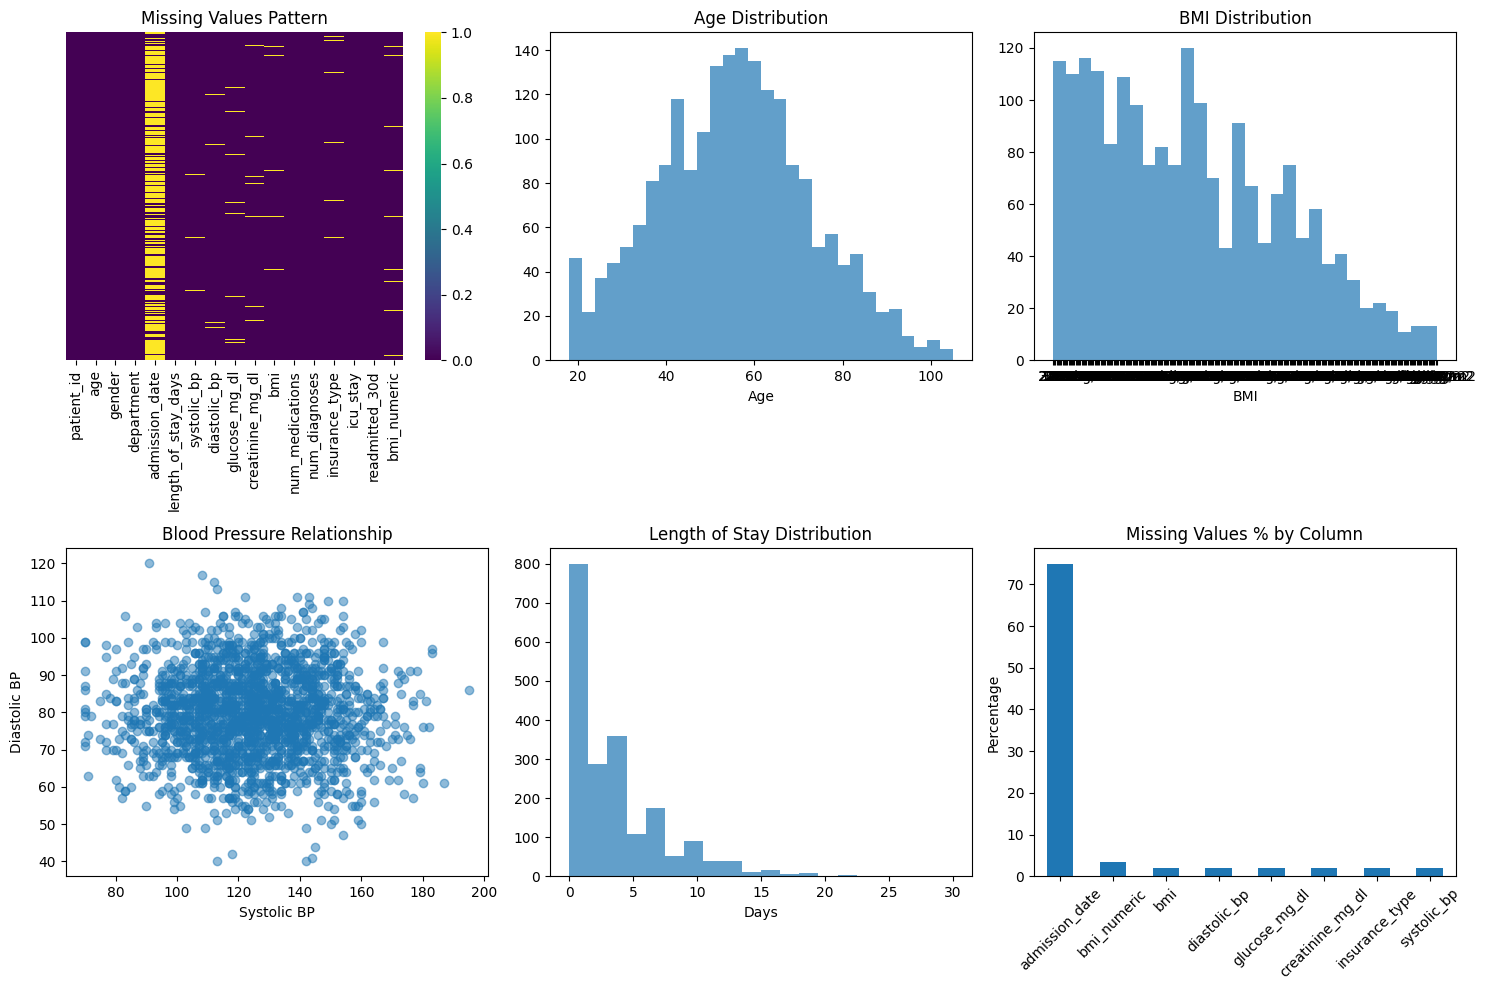

In [32]:
# Data quality visualization
plt.figure(figsize=(15, 10))

# Missing values heatmap
plt.subplot(2, 3, 1)
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Pattern')

# Age distribution
plt.subplot(2, 3, 2)
plt.hist(df['age'].dropna(), bins=30, alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')

# BMI distribution
plt.subplot(2, 3, 3)
plt.hist(df['bmi'].dropna(), bins=30, alpha=0.7)
plt.title('BMI Distribution')
plt.xlabel('BMI')

# Blood pressure scatter
plt.subplot(2, 3, 4)
plt.scatter(df['systolic_bp'], df['diastolic_bp'], alpha=0.5)
plt.xlabel('Systolic BP')
plt.ylabel('Diastolic BP')
plt.title('Blood Pressure Relationship')

# Length of stay
plt.subplot(2, 3, 5)
plt.hist(df['length_of_stay_days'], bins=20, alpha=0.7)
plt.title('Length of Stay Distribution')
plt.xlabel('Days')

# Missing values by column
plt.subplot(2, 3, 6)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].plot(kind='bar')
plt.title('Missing Values % by Column')
plt.ylabel('Percentage')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# STEP 1: FIX DATE PARSING ISSUES
df_clean = df.copy()

def parse_date_flexible(date_str):
    if pd.isna(date_str):
        return None
    
    date_str = str(date_str).strip()
    formats = ['%Y-%m-%d', '%d-%m-%Y', '%d/%m/%Y', '%m/%d/%Y', '%Y/%m/%d', '%d-%b-%Y', '%b-%d-%Y']
    
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except:
            continue
    
    try:
        return pd.to_datetime(date_str, dayfirst=True, errors='coerce')
    except:
        return None

df_clean['admission_date_cleaned'] = df_clean['admission_date'].apply(parse_date_flexible)
print(f"Before cleaning: {df_clean['admission_date'].isnull().sum()} null dates")
print(f"After cleaning: {df_clean['admission_date_cleaned'].isnull().sum()} null dates")

df_clean['admission_date'] = df_clean['admission_date_cleaned']
df_clean = df_clean.drop('admission_date_cleaned', axis=1)
print(f"Final date range: {df_clean['admission_date'].min()} to {df_clean['admission_date'].max()}")

Before cleaning: 1497 null dates
After cleaning: 1497 null dates
Final date range: 2022-01-02 00:00:00 to 2023-12-30 00:00:00


/tmp/ipykernel_26348/4024372996.py:18: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(date_str, dayfirst=True, errors='coerce')


In [34]:
# STEP 2: CLEAN BMI COLUMN
def clean_bmi(bmi_value):
    if pd.isna(bmi_value):
        return None
    
    bmi_str = str(bmi_value).strip()
    bmi_str = bmi_str.replace('kg/m2', '').replace('kg/m²', '').replace('kg/m^2', '')
    bmi_str = bmi_str.replace('kg', '').replace('m2', '').replace('m²', '').strip()
    
    try:
        bmi_numeric = float(bmi_str)
        if bmi_numeric < 0 or bmi_numeric > 60:
            return None
        return bmi_numeric
    except:
        return None

df_clean['bmi_cleaned'] = df_clean['bmi'].apply(clean_bmi)
print(f"Successfully cleaned BMI values: {df_clean['bmi_cleaned'].notna().sum()}")
print(f"Remaining null BMI values: {df_clean['bmi_cleaned'].isnull().sum()}")

df_clean['bmi'] = df_clean['bmi_cleaned']
df_clean = df_clean.drop(['bmi_cleaned', 'bmi_numeric'], axis=1)

Successfully cleaned BMI values: 1941
Remaining null BMI values: 59


In [36]:
# STEP 3: STANDARDIZE CATEGORICAL VARIABLES
gender_mapping = {'M': 'Male', 'm': 'Male', 'Male': 'Male', 'F': 'Female', 'f': 'Female', 'Female': 'Female', 'Unknown': 'Unknown'}
df_clean['gender'] = df_clean['gender'].map(gender_mapping)

df_clean['department'] = df_clean['department'].str.strip().str.title()
df_clean['insurance_type'] = df_clean['insurance_type'].str.strip().str.title()

print("Gender:", df_clean['gender'].value_counts().to_dict())
print("Department:", df_clean['department'].value_counts().to_dict())
print("Insurance:", df_clean['insurance_type'].value_counts().to_dict())

Gender: {'Male': 942, 'Female': 876, 'Unknown': 182}
Department: {'Cardiology': 745, 'Neurology': 283, 'Emergency': 263, 'General Medicine': 247, 'Pediatrics': 241, 'Orthopaedics': 221}
Insurance: {'Government': 561, 'Private': 522, 'Self-Pay': 393, 'Cghs': 306, 'Esi': 178}


In [38]:
# STEP 4: CORRECT BLOOD PRESSURE ERRORS
bp_issues = df_clean[df_clean['systolic_bp'] <= df_clean['diastolic_bp']]
print(f"Records with BP issues: {len(bp_issues)}")

def correct_bp_values(row):
    systolic, diastolic = row['systolic_bp'], row['diastolic_bp']
    
    if pd.isna(systolic) or pd.isna(diastolic):
        return systolic, diastolic
    
    if systolic <= diastolic and (60 <= diastolic <= 200) and (40 <= systolic <= 120):
        return diastolic, systolic
    elif systolic <= diastolic:
        return None, None
    
    return systolic, diastolic

bp_results = df_clean.apply(correct_bp_values, axis=1)
df_clean['systolic_bp'] = [result[0] for result in bp_results]
df_clean['diastolic_bp'] = [result[1] for result in bp_results]

remaining_issues = df_clean[df_clean['systolic_bp'] <= df_clean['diastolic_bp']]
print(f"Remaining BP issues: {len(remaining_issues)}")

Records with BP issues: 6
Remaining BP issues: 6


In [39]:
# STEP 5: IMPUTE MISSING VALUES
print("Missing values before imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Clinical measurements - median imputation
clinical_cols = ['systolic_bp', 'diastolic_bp', 'glucose_mg_dl', 'creatinine_mg_dl', 'bmi']
for col in clinical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"{col}: Imputed with median {median_val:.2f}")

# Categorical - mode imputation
if df_clean['insurance_type'].isnull().sum() > 0:
    mode_val = df_clean['insurance_type'].mode()[0]
    df_clean['insurance_type'].fillna(mode_val, inplace=True)
    print(f"insurance_type: Imputed with mode '{mode_val}'")

print("Missing values after imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values before imputation:
admission_date      1497
systolic_bp           40
diastolic_bp          40
glucose_mg_dl         40
creatinine_mg_dl      40
bmi                   59
insurance_type        40
dtype: int64
systolic_bp: Imputed with median 124.00
diastolic_bp: Imputed with median 79.00
glucose_mg_dl: Imputed with median 108.50
creatinine_mg_dl: Imputed with median 1.13
bmi: Imputed with median 26.00
insurance_type: Imputed with mode 'Government'
Missing values after imputation:
admission_date      1497
systolic_bp           40
diastolic_bp          40
glucose_mg_dl         40
creatinine_mg_dl      40
bmi                   59
insurance_type        40
dtype: int64


/tmp/ipykernel_26348/2711114866.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(median_val, inplace=True)
/tmp/ipykernel_26348/2711114866.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works 

In [40]:
# STEP 6: FINAL VALIDATION
df_final = df_clean.copy()
print(f"Final dataset shape: {df_final.shape}")

# Quality checks
age_issues = df_final[(df_final['age'] < 0) | (df_final['age'] > 120)]
bmi_issues = df_final[(df_final['bmi'] < 10) | (df_final['bmi'] > 60)]
bp_issues = df_final[df_final['systolic_bp'] <= df_final['diastolic_bp']]

print(f"Age issues: {len(age_issues)}")
print(f"BMI issues: {len(bmi_issues)}")
print(f"BP issues: {len(bp_issues)}")

# Summary statistics
print("\nClinical measurements:")
print(df_final[['systolic_bp', 'diastolic_bp', 'glucose_mg_dl', 'creatinine_mg_dl', 'bmi']].describe())

print(f"\nReadmission rate: {df_final['readmitted_30d'].mean():.2%}")

# Save cleaned dataset
df_final.to_csv('hospital_records_cleaned.csv', index=False)

Final dataset shape: (2000, 16)
Age issues: 0
BMI issues: 0
BP issues: 6

Clinical measurements:
       systolic_bp  diastolic_bp  glucose_mg_dl  creatinine_mg_dl          bmi
count  1960.000000   1960.000000    1960.000000       1960.000000  1941.000000
mean    124.706122     79.359694     117.854694          1.276235    26.080113
std      20.159075     11.643580      47.434968          0.697916     5.978785
min      71.000000     40.000000      50.000000          0.300000    12.000000
25%     110.000000     72.000000      83.900000          0.800000    22.000000
50%     124.000000     79.000000     108.500000          1.130000    26.000000
75%     139.000000     87.000000     141.425000          1.570000    30.100000
max     195.000000    113.000000     424.600000          6.140000    52.900000

Readmission rate: 6.20%
